
Tree height: 0.001233
Tree length: 0.010186
strictly bifurcating tree

Numbers of objects in tree: 231 (115 nodes and 116 leaves)



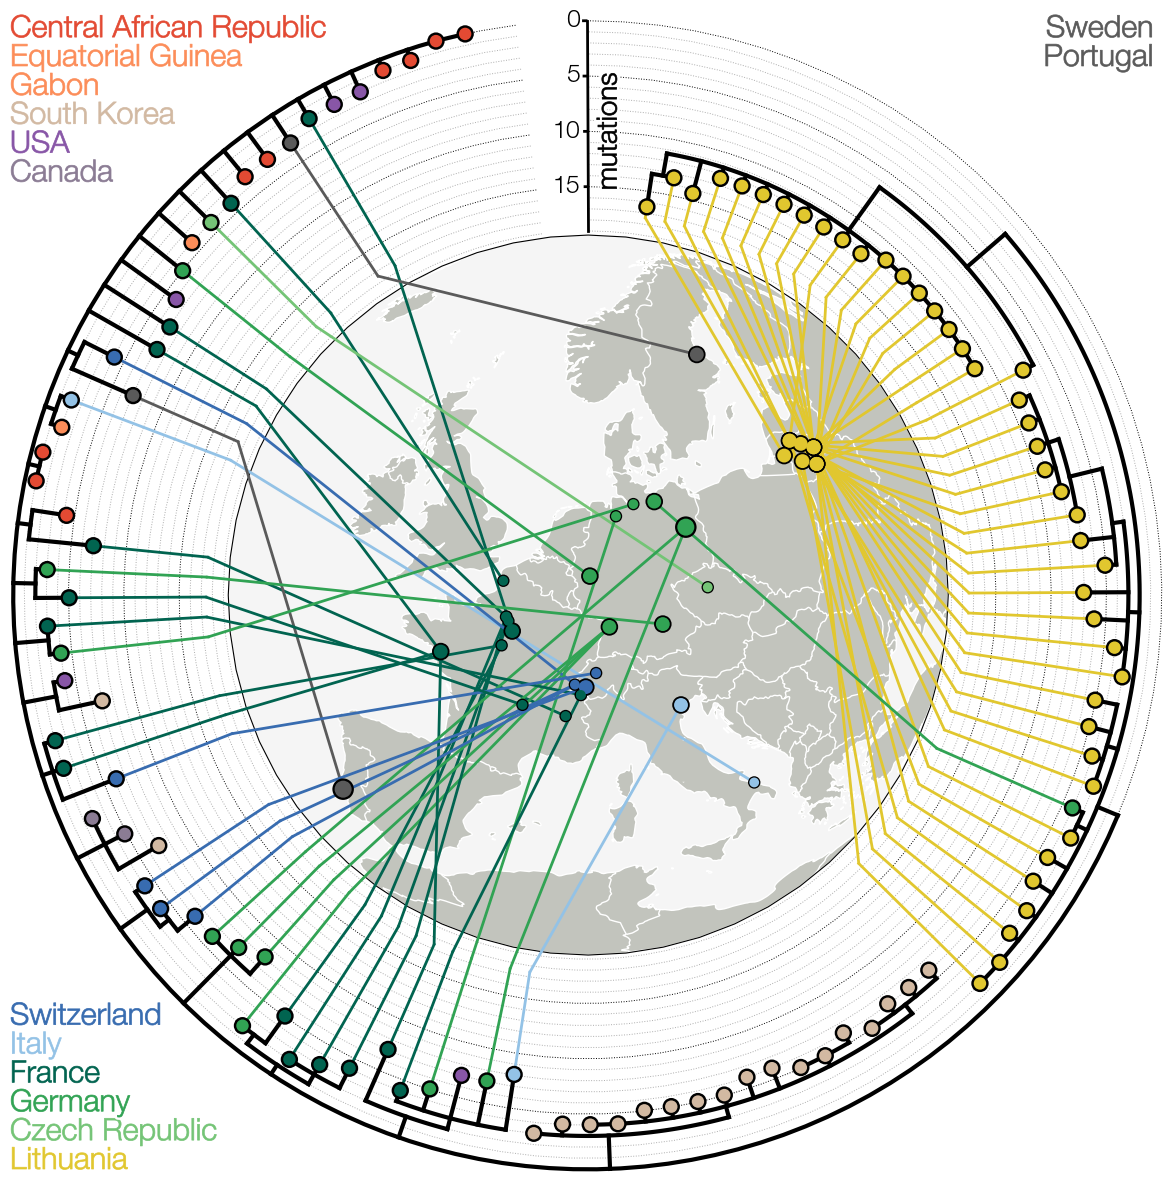

In [1]:
import baltic as bt
from baltic import bt_utils
from baltic import curonia

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch

import numpy as np
import csv, os

################# LOAD METADATA
basePath = '/mnt/c/Users/evogytis/repos/baltic-v1-manuscript/'

metaFile = 'data/Fig-1_B.1.620/travel_qc_info.csv'

locs = {}

###
for l in csv.DictReader(open(os.path.join(basePath, metaFile), 'r'), delimiter='\t'):
    virName = l['Virus name'].replace(' ','_')
    locStr = [c.strip(' ').replace(' ','_') for c in l['Location'].split('/')][-1]
    locs[virName] = locStr

###
coordinates = {}
locSize = {'town': 1, 'county': 2, 'country': 3}
coordFile = 'data/Fig-1_B.1.620/loc_coords.tsv'

for l in csv.DictReader(open(os.path.join(basePath, coordFile), 'r'), delimiter='\t'):
    loc = l['location']
    lat = float(l['lat'])
    lon = float(l['lon'])
    size = l['size']

    coordinates[loc] = (lat, lon, size)

########### COLOURS
colourFile = 'data/Fig-1_B.1.620/colours.csv'
colours={}
for line in open(os.path.join(basePath, colourFile), 'r'):
    loc, colour = line.strip('\n').split('\t')
    colours[loc.replace(' ', '_')] = colour

########################### TREE IMPORT
treePath = 'data/Fig-1_B.1.620/B.1.620.newick'

ll = bt.io.load_newick(os.path.join(basePath, treePath), 'divergence')
ll.treeStats()

## EXTRACT B.1.620 SUBTREE
ll = ll.subtree(ll.root.children[-1].children[1], stem=False)

for k in ll.Objects:
    if k.length < 1 / 50000:
        k.length = 0.0
ll.traverse_tree()

ll = ll.collapse_branches(lambda k: k.length < 1 / 50000)

### RESCALE TREE TO MUTATIONS
alnL = 29903
for k in ll.get_branches():
    k.length *= alnL

ll.root.length = 0.0
ll.traverse_tree()

############# MAP AXES
import cartopy
import cartopy.crs as ccrs

fig = plt.figure(figsize=(15, 15), facecolor='none')
gs = GridSpec(1, 1)
ax = plt.subplot(gs[0])

proj = ccrs.NearsidePerspective(central_longitude=7, central_latitude=50, satellite_height=800000) ## projection

########## CENTER MAP AXES COORDINATES
w = 0.48
ax2 = fig.add_axes([(1 - w) / 2 + 0.013, (1 - w) / 2 - 0.005, w, w], facecolor='none', projection=proj, zorder=0) ## add sub-axes

ax2.set_autoscale_on(False)

##### TREE
circular = {
    "circStart": 0.52,
    "circFrac": 0.95,
    "inwardSpace": -35.5,
}

colourFxn = lambda k : colours[k.name.split('|')[0].split('/')[1]]

ll.plot_tree(ax, treeType='circular', width=3, precision=100, **circular)
ll.plot_points(ax, treeType='circular', targetFxn=lambda k: k.is_leaf(), colourFxn=colourFxn, pointSize=80, zorder=12, **circular)

### LOCATION POINTS
done = []
presentCountries = []

for virName in filter(lambda k: k in [q.split('|')[0] for q in ll.root.leaves], locs):
    # print(virName)
    loc = locs[virName]

    if loc not in coordinates:
        print(f"Virus {virName} location {loc} does not have coordinates")
        continue
        
    if loc in done:
        continue
        
    lat, lon, locType = coordinates[loc]
    size = locSize[locType]
    
    fc = colours[virName.split('|')[0].split('/')[1]]
    
    ax2.scatter(lon, lat, s=50 * size, fc=fc, ec='none', zorder=10000, transform=ccrs.PlateCarree())
    ax2.scatter(lon, lat, s=80 * size, fc='k', ec='none', zorder=1000, transform=ccrs.PlateCarree())
    
    done.append(loc)

##### LEGEND
for c, country in enumerate(['Switzerland', 'Italy', 'France', 'Germany', 'Czech_Republic', 'Lithuania'][::-1]):
    pathEffects = bt_utils.get_path_effects(mainColour=colours[country], outlineColour='w')
    ax.text(0.0, 0.01 + c * 0.025, country.replace('_', ' '), ha='left', va='center', size=22, transform=ax.transAxes, color=colours[country], path_effects=pathEffects)

for c, country in enumerate(['Sweden', 'Portugal']):
    pathEffects = bt_utils.get_path_effects(mainColour=colours[country], outlineColour='w')
    ax.text(0.99, 0.99 - c * 0.025, country.replace('_', ' '), ha='right', va='center', size=22, transform=ax.transAxes, color=colours[country], path_effects=pathEffects)

for c, country in enumerate(['Central_African_Republic', 'Equatorial_Guinea', 'Gabon', 'South_Korea', 'USA', 'Canada']):
    pathEffects = bt_utils.get_path_effects(mainColour=colours[country], outlineColour='w')
    ax.text(0.0, 0.99 - c * 0.025, country.replace('_', ' '), ha='left', va='center', size=22, transform=ax.transAxes, color=colours[country], path_effects=pathEffects)

########### CONNECTIONS
# Curonia expects {complete_tip_name: (latitude, longitude)}.
tipCoordinates = {
    k.name: coordinates[locs[k.name.split('|')[0]]][:2]
    for k in ll.get_external()
    if locs[k.name.split('|')[0]] in coordinates
}

ax2.set_global() ## this call has to be before connection plotting

curonia.connect_tree_to_map(
    treeAx=ax,
    mapAx=ax2,
    tree=ll,
    tipCoordinates=tipCoordinates,
    destinationProjection=proj,
    originProjection=ccrs.PlateCarree(),
    targetFxn=lambda k: k.name in tipCoordinates,
    colourFxn=colourFxn,

    # Actual plotted circular tip position.
    treePositionFxn=lambda k: ll.project_circular_point(k.height, k.y, **circular),

    # Route the connection slightly beyond the outside of the tree.
    shoulderPositionFxn=lambda k: ll.project_circular_point(ll.treeHeight + 1.0, k.y, **circular),

    lw=2,
    zorder=10,
    clip_on=False,
)
########## SCALE BAR

mid = -np.pi / 2
scaleBarTreeY = (0.25 - mid / (2 * np.pi) - circular['circStart']) * ll.ySpan / circular['circFrac']

barStart = 0
barEnd = int(ll.treeHeight) + 3

bar = np.asarray([
    ll.project_circular_point(barStart, scaleBarTreeY, **circular),
    ll.project_circular_point(barEnd, scaleBarTreeY, **circular),
])

ax.plot(bar[:, 0], bar[:, 1], color='k', lw=2)

########## SCALE RINGS, TICKS, AND LABELS

for marker in range(0, int(ll.treeHeight) + 4):
    ringAngles = np.linspace(mid + 0.04 * np.pi, mid + 2 * np.pi, 100)
    ringTreeYs = (0.25 - ringAngles / (2 * np.pi) - circular['circStart']) * ll.ySpan / circular['circFrac']

    ring = np.asarray([
        ll.project_circular_point(marker, treeY, **circular)
        for treeY in ringTreeYs
    ])

    ringColour = '#adadad' if marker % 5 else 'k'
    ax.plot(ring[:, 0], ring[:, 1], ls=':', lw=0.7, color=ringColour, zorder=0)

    if marker % 5 == 0 and marker != 20:
        tickAngles = np.linspace(mid + 0.003 * np.pi, mid, 5)
        tickTreeYs = (0.25 - tickAngles / (2 * np.pi) - circular['circStart']) * ll.ySpan / circular['circFrac']

        tick = np.asarray([
            ll.project_circular_point(marker, treeY, **circular)
            for treeY in tickTreeYs
        ])

        ax.plot(tick[:, 0], tick[:, 1], color='k', ls='--', lw=2)

        labelX, labelY = ll.project_circular_point(marker, scaleBarTreeY, **circular)
        ax.text(labelX - 0.04, labelY, marker, ha='right', va='center', size=18, zorder=2000000, clip_on=False)

        if marker == 10:
            pathEffects = bt_utils.get_path_effects(mainColour='k', outlineColour='w')
            ax.text(labelX + 0.05, labelY, 'mutations', size=20, rotation=90, ha='center', va='top', rotation_mode='anchor', path_effects=pathEffects)

########
[ax.spines[loc].set_visible(False) for loc in ax.spines] ## no spines for the plot
[ax2.spines[loc].set_visible(False) for loc in ax.spines] ## no spines for the plot

########### FEAUTRES
scale='50m'
water='#f5f5f5'
land='#C2C4BD'

## add water bodies, continents and country borders
ax2.add_feature(cartopy.feature.LAKES.with_scale(scale), facecolor=water, zorder=0)
ax2.add_feature(cartopy.feature.OCEAN.with_scale(scale), facecolor=water, edgecolor=water, zorder=0)
ax2.add_feature(cartopy.feature.LAND.with_scale(scale), facecolor=land, edgecolor='w', zorder=1)
ax2.add_feature(cartopy.feature.BORDERS.with_scale(scale), edgecolor='w', lw=1,zorder=1)

#####
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(size=0)
#########

treeLimits = 3.18
ax.set_xlim(-treeLimits, treeLimits)
ax.set_ylim(-treeLimits, treeLimits)

#####
plt.savefig(os.path.join(basePath,'figures/Fig1_circMap.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(basePath,'figures/Fig1_circMap.pdf'), dpi=300, bbox_inches='tight')
plt.show()